In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import seaborn as sns

In [3]:
df1 = pd.read_csv('/Users/test/Desktop/GP5/DL_project_5/data/nlp_product_dataset.csv')
df2 = pd.read_csv('/Users/test/Desktop/GP5/DL_project_5/data/nlp_issue_dataset.csv')

In [4]:
df1.shape, df2.shape

((53898, 2), (53898, 2))

In [5]:
df1['Issue'] = df2['Issue']
df1

,Consumer complaint narrative,Product,Issue
0,I mobile deposited a XXXX check to Ameris Bank...,Checking or savings account,Managing an account
1,"Credence Resource Management , LLC ( Use the a...",Debt collection,Attempts to collect debt not owed
2,"Help my rights are being violated, 15 U.S.C. 1...",Debt collection,Took or threatened to take negative or legal a...
3,This company is violating my rights they have ...,Debt collection,Took or threatened to take negative or legal a...
4,My information was heisted and this accounts a...,Credit card,Other
...,...,...,...
53893,My credit reports are inaccurate. These inaccu...,Credit reporting or other personal consumer re...,Incorrect information on your report
53894,I received a very shady voicemail from structu...,Debt collection,Other
53895,In XXXX of XXXX I was charged for a Best Buy r...,Credit card,Problem with a purchase shown on your statement
53896,"My name is XXXX XXXX, residing at XXXX XXXX XX...",Debt collection,Attempts to collect debt not owed


In [6]:
df1["Product"].value_counts()

Product
Debt collection                                        23143
Checking or savings account                            11671
Credit card                                            11373
Money transfer, virtual currency, or money service      4998
Credit reporting or other personal consumer reports     2713
Name: count, dtype: int64

In [7]:
df1["Issue"].value_counts()

Issue
Other                                                           15362
Attempts to collect debt not owed                               12106
Managing an account                                              6592
Written notification about debt                                  3973
Problem with a purchase shown on your statement                  3915
False statements or representation                               3119
Took or threatened to take negative or legal action              2049
Incorrect information on your report                             1911
Problem with a lender or other company charging your account     1748
Closing an account                                               1597
Fraud or scam                                                    1526
Name: count, dtype: int64

In [8]:
df1["word_count"] = (df1["Consumer complaint narrative"].str.split().str.len())
df1["word_count"].describe()

count    53898.000000
mean       205.468144
std        202.689620
min          6.000000
25%         79.000000
50%        156.000000
75%        265.000000
max       5205.000000
Name: word_count, dtype: float64

In [9]:
product_length = (df1.groupby("Product")["word_count"].agg(["mean", "median", "min", "max"]).round(2))

product_length

,mean,median,min,max
Product,,,,
Checking or savings account,232.60,187.0,7,4695
Credit card,247.65,204.0,6,4950
Credit reporting or other personal consumer reports,178.82,116.0,6,5205
Debt collection,170.35,131.0,6,4547
"Money transfer, virtual currency, or money service",223.19,181.0,9,2625


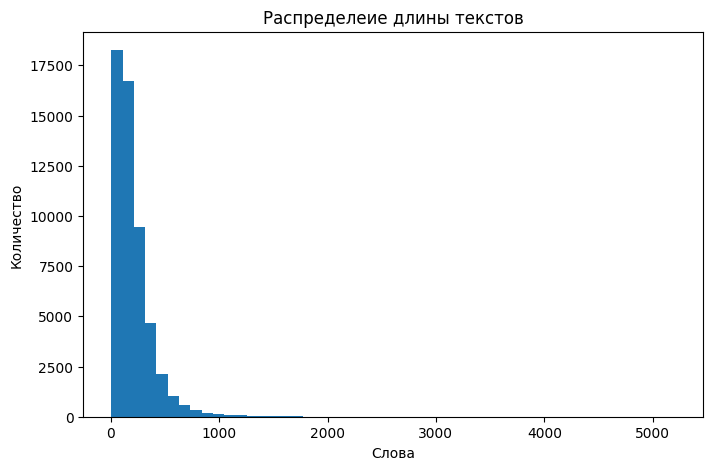

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df1["word_count"], bins=50)

plt.title("Распределеие длины текстов")
plt.xlabel("Слова")
plt.ylabel("Количество")

plt.show()

In [11]:
df1.sort_values("word_count").head(20)

,Consumer complaint narrative,Product,Issue,word_count
20329,THIS ENTRY ERRONEOUSLY IMPLIES PAYMENT NONFULF...,Credit reporting or other personal consumer re...,Incorrect information on your report,6
6165,XXXX account ending XXXX information inaccurate,Debt collection,Written notification about debt,6
10217,personal information forwarded without my cons...,Credit card,Other,6
26161,JEFFERSON CAPITAL SYST Balance {$2200.00} on X...,Debt collection,Took or threatened to take negative or legal a...,7
1075,See attached dispute timeline and supporting d...,Checking or savings account,Problem with a lender or other company chargin...,7
31817,b'Requested information didnt receive still on...,Debt collection,Written notification about debt,7
33772,XXXX XXXX XXXX Last reported XX/XX/year> {$200...,Debt collection,Attempts to collect debt not owed,7
20829,THE ACCOUNT REMAINED FULLY CURRENT WITHOUT INT...,Credit reporting or other personal consumer re...,Incorrect information on your report,7
15415,THIS LATE PAYMENT INDICATOR IS REPORTED IMPROP...,Credit reporting or other personal consumer re...,Incorrect information on your report,7
26369,CS JEFFERSON CAPITAL SYST Balance {$1200.00} X...,Debt collection,Took or threatened to take negative or legal a...,8


In [12]:
all_text = " ".join(df1["Consumer complaint narrative"])

In [13]:
words = all_text.lower().split()

Counter(words).most_common(30)

[('the', 487215),
 ('xxxx', 398767),
 ('i', 329402),
 ('to', 323321),
 ('and', 307389),
 ('a', 218040),
 ('of', 210580),
 ('my', 207451),
 ('that', 149330),
 ('this', 136600),
 ('was', 120189),
 ('not', 106224),
 ('account', 105501),
 ('on', 98793),
 ('is', 95416),
 ('in', 92848),
 ('for', 82015),
 ('credit', 81345),
 ('or', 73496),
 ('with', 72350),
 ('they', 71190),
 ('(', 68200),
 ('have', 68161),
 (':', 63590),
 ('as', 56623),
 ('from', 54603),
 ('am', 54072),
 ('me', 53397),
 ('debt', 49719),
 ('it', 47998)]

In [14]:
for product in df1["Product"].unique():

    text = " ".join(df1[df1["Product"] == product]["Consumer complaint narrative"])

    words = text.lower().split()

    print(product)
    print(Counter(words).most_common(15))

Checking or savings account
[('the', 119386), ('xxxx', 92705), ('i', 91287), ('to', 82628), ('and', 78713), ('my', 61308), ('a', 55576), ('of', 45184), ('was', 38898), ('that', 38127), ('account', 28547), ('not', 26203), ('on', 25995), ('this', 25409), ('in', 24373)]
Debt collection
[('the', 173392), ('xxxx', 135028), ('to', 113361), ('and', 106342), ('i', 100376), ('of', 91114), ('a', 70175), ('this', 65127), ('my', 63189), ('that', 51333), ('debt', 47790), ('is', 47737), ('credit', 43143), ('account', 41916), ('not', 36771)]
Credit card
[('the', 130443), ('i', 93386), ('xxxx', 93173), ('to', 80726), ('and', 76265), ('a', 61205), ('my', 50720), ('of', 45883), ('that', 40355), ('was', 39995), ('on', 29878), ('this', 29660), ('not', 28743), ('in', 26352), ('for', 24975)]
Money transfer, virtual currency, or money service
[('the', 47391), ('xxxx', 43201), ('i', 35543), ('to', 35451), ('and', 32333), ('my', 24249), ('a', 22963), ('of', 17889), ('was', 15692), ('that', 14799), ('this', 103

In [15]:
words = re.findall(r"[a-z]+", all_text.lower())

custom_stopwords = {"xxxx", "xx", "xxx", "s", "u"}

words = [w for w in words if w not in ENGLISH_STOP_WORDS and w not in custom_stopwords]

In [16]:
Counter(words).most_common(30)

[('account', 130426),
 ('credit', 89854),
 ('debt', 65724),
 ('reporting', 47350),
 ('bank', 38213),
 ('information', 37086),
 ('dispute', 32153),
 ('report', 31793),
 ('card', 31555),
 ('collection', 30322),
 ('payment', 27059),
 ('provide', 26294),
 ('did', 25024),
 ('year', 24608),
 ('balance', 23352),
 ('documentation', 22744),
 ('request', 22590),
 ('consumer', 21282),
 ('received', 21234),
 ('funds', 21001),
 ('act', 20246),
 ('provided', 19932),
 ('complaint', 19772),
 ('fair', 19234),
 ('accounts', 19016),
 ('validation', 18461),
 ('reported', 17998),
 ('number', 17575),
 ('investigation', 17395),
 ('including', 17275)]

In [17]:
for product in df1["Product"].unique():

    text = " ".join(df1[df1["Product"] == product]["Consumer complaint narrative"])

    words = re.findall(r"[a-z]+", text.lower())

    words = [w for w in words if w not in ENGLISH_STOP_WORDS and w not in custom_stopwords]

    print(product)
    print(Counter(words).most_common(20))

Checking or savings account
[('account', 36674), ('bank', 19863), ('funds', 12596), ('did', 7904), ('money', 7571), ('year', 7522), ('transactions', 7356), ('card', 7288), ('fraud', 7010), ('check', 6774), ('transaction', 6460), ('dispute', 6411), ('told', 6243), ('wells', 6189), ('credit', 6048), ('fargo', 5753), ('received', 5730), ('claim', 5676), ('unauthorized', 5581), ('information', 5537)]
Debt collection
[('debt', 63138), ('credit', 49277), ('account', 48859), ('reporting', 36058), ('collection', 28784), ('report', 19823), ('information', 19178), ('validation', 17641), ('act', 14614), ('fair', 14470), ('original', 14191), ('provide', 14153), ('request', 12800), ('documentation', 12577), ('c', 12111), ('consumer', 11501), ('dispute', 11339), ('alleged', 11172), ('verification', 10938), ('inaccurate', 10389)]
Credit card
[('account', 26275), ('credit', 25900), ('card', 20755), ('payment', 11346), ('bank', 10836), ('dispute', 10615), ('balance', 8105), ('did', 7827), ('year', 7662

In [18]:
def clean_text(text):

    text = str(text).lower()

    words = re.findall(r"[a-z]+", text)

    words = [
        w for w in words
        if w not in {"xxxx", "xx", "xxx"}
    ]

    return " ".join(words)

In [19]:
df1["clean_text"] = (df1["Consumer complaint narrative"].apply(clean_text))
df1

,Consumer complaint narrative,Product,Issue,word_count,clean_text
0,I mobile deposited a XXXX check to Ameris Bank...,Checking or savings account,Managing an account,188,i mobile deposited a check to ameris bank on y...
1,"Credence Resource Management , LLC ( Use the a...",Debt collection,Attempts to collect debt not owed,332,credence resource management llc use the addre...
2,"Help my rights are being violated, 15 U.S.C. 1...",Debt collection,Took or threatened to take negative or legal a...,85,help my rights are being violated u s c g b of...
3,This company is violating my rights they have ...,Debt collection,Took or threatened to take negative or legal a...,74,this company is violating my rights they have ...
4,My information was heisted and this accounts a...,Credit card,Other,31,my information was heisted and this accounts a...
...,...,...,...,...,...
53893,My credit reports are inaccurate. These inaccu...,Credit reporting or other personal consumer re...,Incorrect information on your report,39,my credit reports are inaccurate these inaccur...
53894,I received a very shady voicemail from structu...,Debt collection,Other,39,i received a very shady voicemail from structu...
53895,In XXXX of XXXX I was charged for a Best Buy r...,Credit card,Problem with a purchase shown on your statement,434,in of i was charged for a best buy renewal of ...
53896,"My name is XXXX XXXX, residing at XXXX XXXX XX...",Debt collection,Attempts to collect debt not owed,277,my name is residing at ga my date of birth is ...


In [20]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_tfidf = vectorizer.fit_transform(df1["clean_text"])

In [21]:
X_tfidf.shape

(53898, 5000)

In [22]:
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

In [23]:
tfidf_df

,aadvantage,aafes,aargon,abandoned,abiding,ability,able,abroad,abrupt,abruptly,...,yield,york,young,youre,yrs,zelle,zero,zion,zions,zip
0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53893,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53894,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53895,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53896,0.0,0.0,0.0,0.0,0.0,0.07818,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
for product in df1["Product"].unique():

    idx = df1["Product"] == product

    top_words = (
        tfidf_df[idx]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )
    print(product)

    print(top_words)

Checking or savings account
account         0.078555
bank            0.071753
funds           0.052116
money           0.039857
check           0.036543
transactions    0.033948
wells           0.031667
fargo           0.030101
fraud           0.028066
year            0.027947
transaction     0.027083
card            0.026629
did             0.026343
told            0.026083
chase           0.025862
dtype: float64
Debt collection
debt            0.142791
credit          0.092689
reporting       0.083585
collection      0.068905
account         0.064304
falsely         0.058236
report          0.054591
validation      0.050262
information     0.040489
rights          0.040017
original        0.040013
verification    0.038219
fair            0.038192
act             0.037791
fdcpa           0.034314
dtype: float64
Credit card
card        0.078750
credit      0.062530
account     0.053614
payment     0.039483
bank        0.036823
balance     0.030782
charge      0.030058
dispute     0.029

In [28]:
%pip install -q dagshub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

In [25]:
import dagshub
import mlflow

In [26]:
dagshub.init(repo_owner='kulikanton05', repo_name='GP5', mlflow=True)

Accessing as kulikanton05

Initialized MLflow to track repo "kulikanton05/GP5"

Repository kulikanton05/GP5 initialized!

In [27]:
X = df1["clean_text"]

y_product = df1["Product"]

y_issue = df1["Issue"]

In [28]:
le_product = LabelEncoder()
le_issue = LabelEncoder()

y_product_en = le_product.fit_transform(y_product)
y_issue_en = le_issue.fit_transform(y_issue)

In [29]:
dict(zip(le_product.classes_, le_product.transform(le_product.classes_)))

{'Checking or savings account': np.int64(0),
 'Credit card': np.int64(1),
 'Credit reporting or other personal consumer reports': np.int64(2),
 'Debt collection': np.int64(3),
 'Money transfer, virtual currency, or money service': np.int64(4)}

In [30]:
dict(zip(le_issue.classes_, le_issue.transform(le_issue.classes_)))

{'Attempts to collect debt not owed': np.int64(0),
 'Closing an account': np.int64(1),
 'False statements or representation': np.int64(2),
 'Fraud or scam': np.int64(3),
 'Incorrect information on your report': np.int64(4),
 'Managing an account': np.int64(5),
 'Other': np.int64(6),
 'Problem with a lender or other company charging your account': np.int64(7),
 'Problem with a purchase shown on your statement': np.int64(8),
 'Took or threatened to take negative or legal action': np.int64(9),
 'Written notification about debt': np.int64(10)}

In [31]:
X_train_prod, X_test_prod, y_train_prod, y_test_prod = train_test_split(X, y_product_en, test_size=0.2, random_state=42, stratify=y_product_en)

In [32]:
X_train_issue, X_test_issue, y_train_issue, y_test_issue = train_test_split(X, y_issue_en, test_size=0.2, random_state=42, stratify=y_issue_en)

In [38]:
print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: https://dagshub.com/kulikanton05/GP5.mlflow


In [39]:
mlflow.set_experiment("Product_Classification")

<Experiment: artifact_location='mlflow-artifacts:/5b922e0b4940479c8da5399530ab31be', creation_time=1781271402977, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1781271402977, lifecycle_stage='active', name='Product_Classification', tags={}, trace_location=None, workspace='default'>

In [39]:
with mlflow.start_run(run_name="logreg_tfidf"):

    params = {
        "model": "LogisticRegression",
        "vectorizer": "TF-IDF",
        "max_features": 5000,
        "stop_words": "english",
        "test_size": 0.2,
        "random_state": 42,
        "target": "Product"
    }

    mlflow.log_params(params)

    vectorizer_prod = TfidfVectorizer(stop_words="english",max_features=5000)
    X_train_tfidf_prod = vectorizer_prod.fit_transform(X_train_prod)
    X_test_tfidf_prod = vectorizer_prod.transform(X_test_prod)

    model_prod = LogisticRegression(random_state=42, max_iter=1000)
    model_prod.fit(X_train_tfidf_prod, y_train_prod)

    y_pred_prod = model_prod.predict(X_test_tfidf_prod)

    acc = accuracy_score(y_test_prod, y_pred_prod)
    precision = precision_score(y_test_prod, y_pred_prod, average="macro")
    recall = recall_score(y_test_prod, y_pred_prod, average="macro")
    f1 = f1_score(y_test_prod, y_pred_prod, average="macro")

    mlflow.log_metrics({
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    })

    mlflow.sklearn.log_model(model_prod, "product_model")

2026/06/12 13:38:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 13:38:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run logreg_tfidf at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/0/runs/ff165269ecef4f71a20f83070f6d9bba
🧪 View experiment at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/0


In [35]:
with mlflow.start_run(run_name="logreg_tfidf_bigrams"):

    params = {
        "model": "LogisticRegression",
        "vectorizer": "TF-IDF",
        "max_features": 5000,
        "ngram_range": "(1,2)",
        "stop_words": "english",
        "test_size": 0.2,
        "random_state": 42,
        "target": "Product"
    }

    mlflow.log_params(params)

    vectorizer_prod_bigram = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
    X_train_tfidf_prod = vectorizer_prod_bigram.fit_transform(X_train_prod)
    X_test_tfidf_prod = vectorizer_prod_bigram.transform(X_test_prod)

    model_prod = LogisticRegression(random_state=42, max_iter=1000)
    model_prod.fit(X_train_tfidf_prod, y_train_prod)

    y_pred_prod = model_prod.predict(X_test_tfidf_prod)

    acc = accuracy_score(y_test_prod, y_pred_prod)
    precision = precision_score(y_test_prod, y_pred_prod, average="macro")
    recall = recall_score(y_test_prod, y_pred_prod, average="macro")
    f1 = f1_score(y_test_prod, y_pred_prod, average="macro")

    mlflow.log_metrics({
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    })

    mlflow.sklearn.log_model(model_prod, "product_model_1")

2026/06/12 17:50:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 17:50:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run logreg_tfidf_bigrams at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/0/runs/c942e6cb1b3b4ca498c2b9862cddd32a
🧪 View experiment at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/0


In [40]:
with mlflow.start_run(run_name="logreg_tfidf2"):

    params = {
        "model": "LogisticRegression",
        "vectorizer": "TF-IDF",
        "max_features": 10000,
        "stop_words": "english",
        "test_size": 0.2,
        "random_state": 42,
        "target": "Product"
    }

    mlflow.log_params(params)

    vectorizer_prod = TfidfVectorizer(stop_words="english",max_features=10000)
    X_train_tfidf_prod = vectorizer_prod.fit_transform(X_train_prod)
    X_test_tfidf_prod = vectorizer_prod.transform(X_test_prod)

    model_prod = LogisticRegression(random_state=42, max_iter=1000)
    model_prod.fit(X_train_tfidf_prod, y_train_prod)

    y_pred_prod = model_prod.predict(X_test_tfidf_prod)

    acc = accuracy_score(y_test_prod, y_pred_prod)
    precision = precision_score(y_test_prod, y_pred_prod, average="macro")
    recall = recall_score(y_test_prod, y_pred_prod, average="macro")
    f1 = f1_score(y_test_prod, y_pred_prod, average="macro")

    mlflow.log_metrics({
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    })

    mlflow.sklearn.log_model(model_prod, "product_model_2")

2026/06/12 18:13:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 18:13:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run logreg_tfidf2 at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/0/runs/504cee9dabff45df806e06b0ea430a6d
🧪 View experiment at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/0


In [41]:
print(classification_report(y_test_prod, y_pred_prod, target_names=le_product.classes_))

                                                     precision    recall  f1-score   support

                        Checking or savings account       0.79      0.85      0.82      2334
                                        Credit card       0.86      0.84      0.85      2275
Credit reporting or other personal consumer reports       0.84      0.77      0.81       542
                                    Debt collection       0.94      0.95      0.95      4629
 Money transfer, virtual currency, or money service       0.75      0.64      0.69      1000

                                           accuracy                           0.87     10780
                                          macro avg       0.84      0.81      0.82     10780
                                       weighted avg       0.87      0.87      0.87     10780



In [36]:
mlflow.set_experiment("Issue_Classification")

<Experiment: artifact_location='mlflow-artifacts:/a98e7b10b72d4f50a6cf38f3959fdc39', creation_time=1781271603911, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781271603911, lifecycle_stage='active', name='Issue_Classification', tags={}, trace_location=None, workspace='default'>

In [ ]:
with mlflow.start_run(run_name="logreg_tfidf"):

    params = {
        "model": "LogisticRegression",
        "vectorizer": "TF-IDF",
        "max_features": 5000,
        "stop_words": "english",
        "test_size": 0.2,
        "random_state": 42,
        "target": "Issue"
    }

    mlflow.log_params(params)

    vectorizer_issue = TfidfVectorizer(stop_words="english", max_features=5000)
    X_train_tfidf_issue = vectorizer_issue.fit_transform(X_train_issue)
    X_test_tfidf_issue = vectorizer_issue.transform(X_test_issue)

    model_issue = LogisticRegression(random_state=42, max_iter=1000)
    model_issue.fit(X_train_tfidf_issue, y_train_issue)

    y_pred_issue = model_issue.predict(X_test_tfidf_issue)

    acc = accuracy_score(y_test_issue, y_pred_issue)
    precision = precision_score(y_test_issue, y_pred_issue, average="macro")
    recall = recall_score(y_test_issue, y_pred_issue, average="macro")
    f1 = f1_score(y_test_issue, y_pred_issue, average="macro")

    mlflow.log_metrics({
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    })

    mlflow.sklearn.log_model(model_issue, "product_model")

2026/06/12 13:40:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 13:40:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run logreg_tfidf at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/1/runs/e439a541dca34e61bc5f1539cf82813b
🧪 View experiment at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/1


In [43]:
print(classification_report(y_test_issue, y_pred_issue, target_names=le_issue.classes_))

                                                              precision    recall  f1-score   support

                           Attempts to collect debt not owed       0.70      0.83      0.76      2421
                                          Closing an account       0.66      0.40      0.50       319
                          False statements or representation       0.56      0.35      0.43       624
                                               Fraud or scam       0.59      0.33      0.43       305
                        Incorrect information on your report       0.67      0.52      0.58       382
                                         Managing an account       0.59      0.64      0.61      1318
                                                       Other       0.66      0.80      0.72      3073
Problem with a lender or other company charging your account       0.49      0.19      0.28       350
             Problem with a purchase shown on your statement       0.74      0.69

In [37]:
with mlflow.start_run(run_name="logreg_tfidf_bigram"):

    params = {
        "model": "LogisticRegression",
        "vectorizer": "TF-IDF",
        "max_features": 5000,
        "ngram_range": "(1,2)",
        "stop_words": "english",
        "test_size": 0.2,
        "random_state": 42,
        "target": "Issue"
    }

    mlflow.log_params(params)

    vectorizer_issue_bigram = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
    X_train_tfidf_issue = vectorizer_issue_bigram.fit_transform(X_train_issue)
    X_test_tfidf_issue = vectorizer_issue_bigram.transform(X_test_issue)

    model_issue = LogisticRegression(random_state=42, max_iter=1000)
    model_issue.fit(X_train_tfidf_issue, y_train_issue)

    y_pred_issue = model_issue.predict(X_test_tfidf_issue)

    acc = accuracy_score(y_test_issue, y_pred_issue)
    precision = precision_score(y_test_issue, y_pred_issue, average="macro")
    recall = recall_score(y_test_issue, y_pred_issue, average="macro")
    f1 = f1_score(y_test_issue, y_pred_issue, average="macro")

    mlflow.log_metrics({
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    })

    mlflow.sklearn.log_model(model_issue, "product_model")

2026/06/12 17:57:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 17:57:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run logreg_tfidf_bigram at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/1/runs/0716a4777edc449dac0687498260465c
🧪 View experiment at: https://dagshub.com/kulikanton05/GP5.mlflow/#/experiments/1


In [38]:
print(classification_report(y_test_issue, y_pred_issue, target_names=le_issue.classes_))

                                                              precision    recall  f1-score   support

                           Attempts to collect debt not owed       0.70      0.83      0.76      2421
                                          Closing an account       0.67      0.42      0.52       319
                          False statements or representation       0.57      0.36      0.44       624
                                               Fraud or scam       0.60      0.35      0.44       305
                        Incorrect information on your report       0.69      0.51      0.58       382
                                         Managing an account       0.59      0.65      0.62      1318
                                                       Other       0.66      0.80      0.72      3073
Problem with a lender or other company charging your account       0.46      0.20      0.28       350
             Problem with a purchase shown on your statement       0.76      0.70